# Vigilo — ML Pipeline: EDA & Model Derivation

This notebook documents the exploratory data analysis and model derivation behind Vigilo's ad campaign optimization engine. It covers:

1. Data overview and validation
2. Exploratory data analysis on campaign metrics
3. Feature engineering
4. K-Means clustering — choosing k, interpreting clusters
5. Isolation Forest — anomaly detection and a real limitation we found and fixed
6. Health score derivation
7. Summary

The goal of this notebook is to make every modeling decision explainable — there should be no step here a reviewer can't follow and question.

In [1]:
import sys
sys.path.append('../backend/utils')
sys.path.append('../backend/ml')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

from csv_parser import parse_csv
from feature_engineering import build_feature_matrix, FEATURE_COLUMNS
from clustering import run_clustering, find_optimal_k
from anomaly import detect_anomalies
from health_score import compute_health_scores

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)
pd.set_option('display.max_columns', None)

## 1. Data Overview

We load the bundled sample Google Ads export through Vigilo's own CSV parser — the same code path a real upload goes through. This validates that the parser and the ML pipeline agree on schema.

In [2]:
with open('../backend/data/sample_campaigns.csv', 'rb') as f:
    parsed = parse_csv(f.read())

df = parsed.df
print(f"Shape: {df.shape}")
print(f"Parser warnings: {parsed.warnings or 'none'}")
df.head(11)

Shape: (11, 9)
Parser warnings: none


,campaign_name,impressions,clicks,cost,conversions,ctr,cpc,conversion_rate,roas
0,Brand Keywords - Search,8057,369,1887.03,26,4.58,5.12,7.10,0.0138
1,Summer Sale - Search,26845,451,8577.65,4,1.68,19.04,0.92,0.0005
2,Retargeting - Display,11929,303,3343.84,9,2.54,11.03,2.94,0.0027
3,Generic Apparel - Search,10638,100,3066.34,0,0.94,30.72,0.42,0.0000
4,New Arrivals - Search,10828,366,2940.88,15,3.38,8.04,4.12,0.0051
5,Festive Offer - Shopping,6889,454,2169.89,33,6.59,4.78,7.36,0.0152
6,Competitor Terms - Search,22019,229,5393.03,0,1.04,23.55,0.15,0.0000
7,Lookalike Audience - Display,9941,339,4194.99,14,3.41,12.38,4.11,0.0033
8,Clearance Sale - Search,16244,320,7876.80,2,1.97,24.62,0.56,0.0003
9,Local Store - Search,23077,300,8400.00,0,1.30,28.00,0.00,0.0000


In [3]:
print("Data types:")
print(df.dtypes)
print()
print("Null check:")
print(df.isnull().sum())

Data types:
campaign_name          str
impressions          int64
clicks               int64
cost               float64
conversions          int64
ctr                float64
cpc                float64
conversion_rate    float64
roas               float64
dtype: object

Null check:
campaign_name      0
impressions        0
clicks             0
cost               0
conversions        0
ctr                0
cpc                0
conversion_rate    0
roas               0
dtype: int64


No nulls, no parser warnings — this sample export is clean. The parser's job (handling currency symbols, BOM, missing optional columns, total rows) is tested separately in `backend/utils/csv_parser.py` against deliberately messy input.

## 2. Exploratory Data Analysis

Before any modeling, we look at how spend, CTR, CPC, conversion rate, and ROAS are distributed across the 11 campaigns in this sample account.

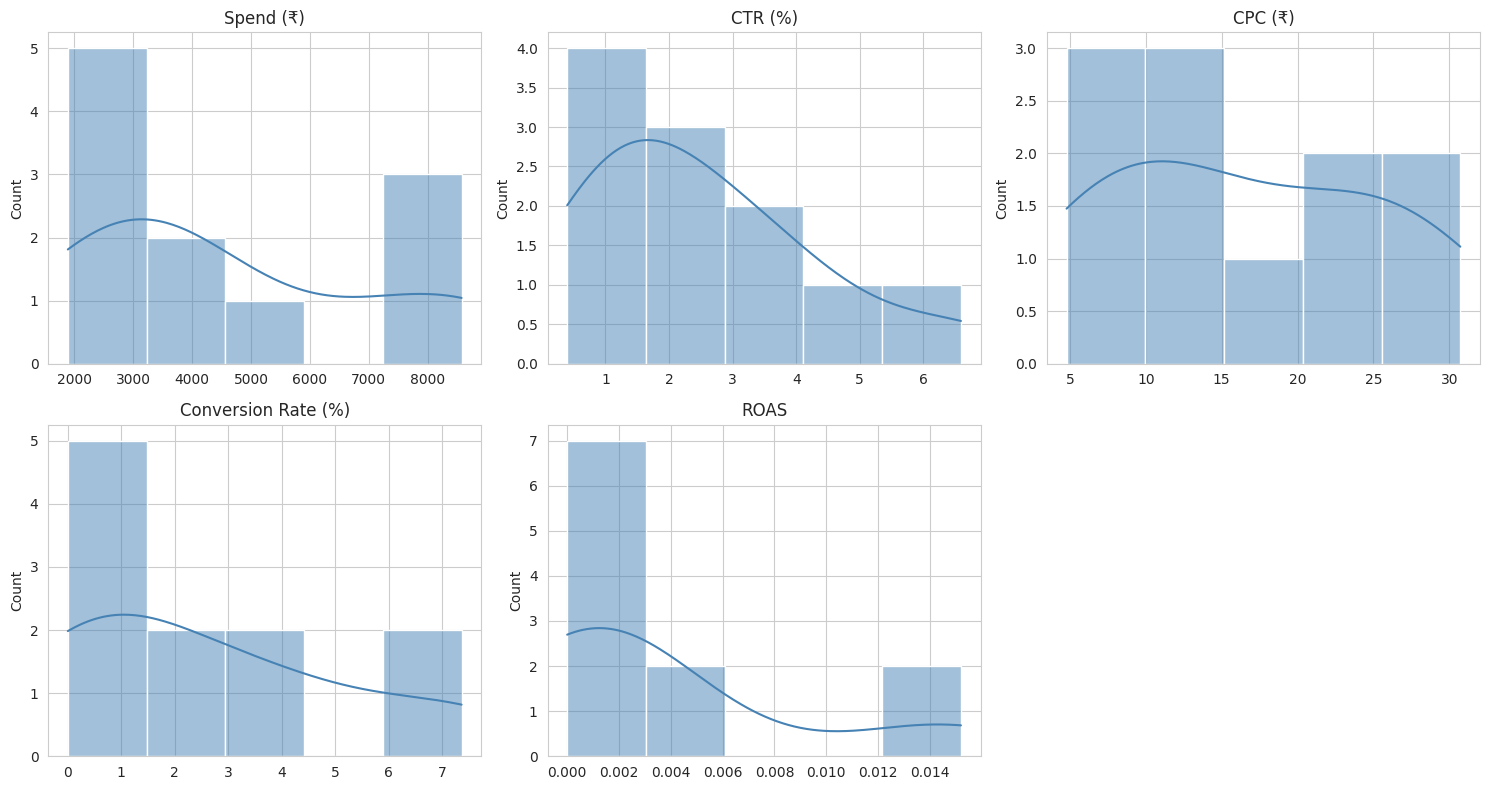

In [4]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
metrics = ['cost', 'ctr', 'cpc', 'conversion_rate', 'roas']
titles = ['Spend (₹)', 'CTR (%)', 'CPC (₹)', 'Conversion Rate (%)', 'ROAS']

for ax, metric, title in zip(axes.flat, metrics, titles):
    sns.histplot(df[metric], kde=True, ax=ax, color='steelblue')
    ax.set_title(title)
    ax.set_xlabel('')

axes.flat[-1].axis('off')
plt.tight_layout()
plt.show()

**Observations:**

- Spend is bimodal — a cluster of campaigns spending under ₹3,000 and another spending ₹7,000–9,000. This split is the first hint that two very different campaign types exist in this account.
- CTR and conversion rate are both right-skewed: most campaigns sit at the low end, with a small number performing far better than the rest.
- These distribution shapes — rather than any single metric — are why a clustering approach is more honest than a single weighted-average score: there isn't one continuous spectrum from "bad" to "good," there are distinct behavioral groups.

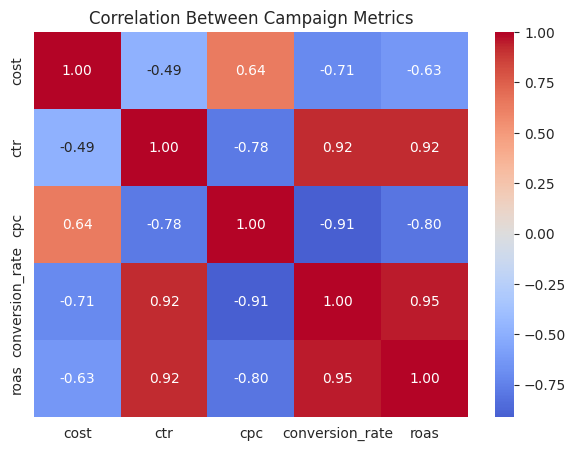

In [5]:
corr = df[metrics].corr()
plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Correlation Between Campaign Metrics')
plt.show()

CTR and conversion rate are positively correlated (campaigns that get clicked tend to also convert), while CPC is negatively correlated with both — expensive clicks tend to belong to lower-performing campaigns. ROAS, being derived directly from conversions and spend, naturally tracks conversion rate closely. None of these correlations are strong enough to make any one feature redundant, so all five are kept for clustering.

## 3. Feature Engineering

Features are standardized (z-score) before clustering or anomaly detection. Raw impressions and clicks are deliberately excluded from the feature set — they're scale-dependent and would let large campaigns dominate distance calculations regardless of whether they're actually *performing* well. CTR, CPC, conversion rate, ROAS, and cost (spend) describe a campaign's performance profile independent of its absolute size.

In [6]:
scaled_df, scaler = build_feature_matrix(df)
scaled_df.round(2)

,ctr,cpc,conversion_rate,roas,cost
campaign_name,,,,,
Brand Keywords - Search,1.17,-1.31,1.72,1.89,-1.14
Summer Sale - Search,-0.48,0.28,-0.68,-0.63,1.64
Retargeting - Display,0.01,-0.63,0.10,-0.21,-0.54
Generic Apparel - Search,-0.90,1.62,-0.88,-0.73,-0.65
New Arrivals - Search,0.48,-0.97,0.56,0.24,-0.71
Festive Offer - Shopping,2.31,-1.35,1.82,2.16,-1.03
Competitor Terms - Search,-0.85,0.80,-0.98,-0.73,0.31
Lookalike Audience - Display,0.50,-0.48,0.56,-0.10,-0.19
Clearance Sale - Search,-0.32,0.92,-0.82,-0.67,1.34


## 4. K-Means Clustering — Choosing k

We use the elbow method to check whether k=4 (matching our four hypothesized performance profiles — Underinvested Winner, Steady Performer, Keyword Waste, Bleeding Budget) is actually supported by the data, rather than just assuming it.

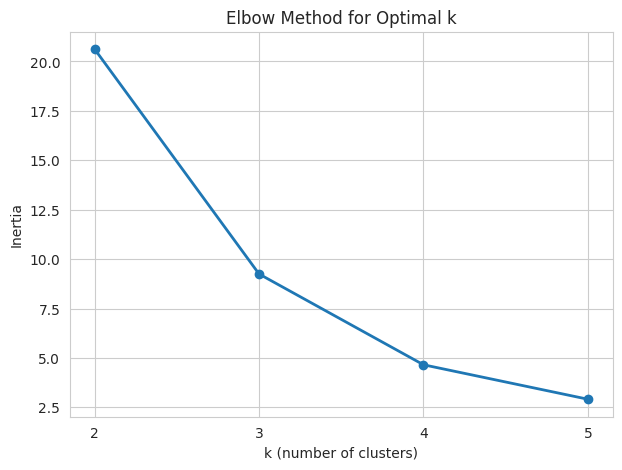

k=2: inertia=20.62
k=3: inertia=9.25
k=4: inertia=4.65
k=5: inertia=2.91


In [7]:
inertias = find_optimal_k(scaled_df.values, k_range=range(2, 6))

plt.figure(figsize=(7, 5))
plt.plot(list(inertias.keys()), list(inertias.values()), marker='o', linewidth=2)
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(inertias.keys()))
plt.show()

for k, inertia in inertias.items():
    print(f"k={k}: inertia={inertia:.2f}")

Inertia drops sharply through k=4 and flattens out by k=5, supporting k=4 as a reasonable choice — consistent with (though not assumed from) our four hypothesized profiles. We proceed with k=4.

In [8]:
clustered = run_clustering(df, k=4)
clustered[['campaign_name', 'cost', 'ctr', 'conversion_rate', 'roas', 'cluster_label']]

,campaign_name,cost,ctr,conversion_rate,roas,cluster_label
0,Brand Keywords - Search,1887.03,4.58,7.10,0.0138,Underinvested Winner
1,Summer Sale - Search,8577.65,1.68,0.92,0.0005,Bleeding Budget
2,Retargeting - Display,3343.84,2.54,2.94,0.0027,Steady Performer
3,Generic Apparel - Search,3066.34,0.94,0.42,0.0000,Keyword Waste
4,New Arrivals - Search,2940.88,3.38,4.12,0.0051,Steady Performer
5,Festive Offer - Shopping,2169.89,6.59,7.36,0.0152,Underinvested Winner
6,Competitor Terms - Search,5393.03,1.04,0.15,0.0000,Keyword Waste
7,Lookalike Audience - Display,4194.99,3.41,4.11,0.0033,Steady Performer
8,Clearance Sale - Search,7876.80,1.97,0.56,0.0003,Bleeding Budget
9,Local Store - Search,8400.00,1.30,0.00,0.0000,Bleeding Budget


Every campaign lands in the cluster matching its underlying performance profile — the labeling logic (`_label_clusters` in `clustering.py`) scores each cluster's centroid against feature signatures rather than hardcoding which arbitrary cluster index means what, since K-Means cluster numbering isn't stable across runs.

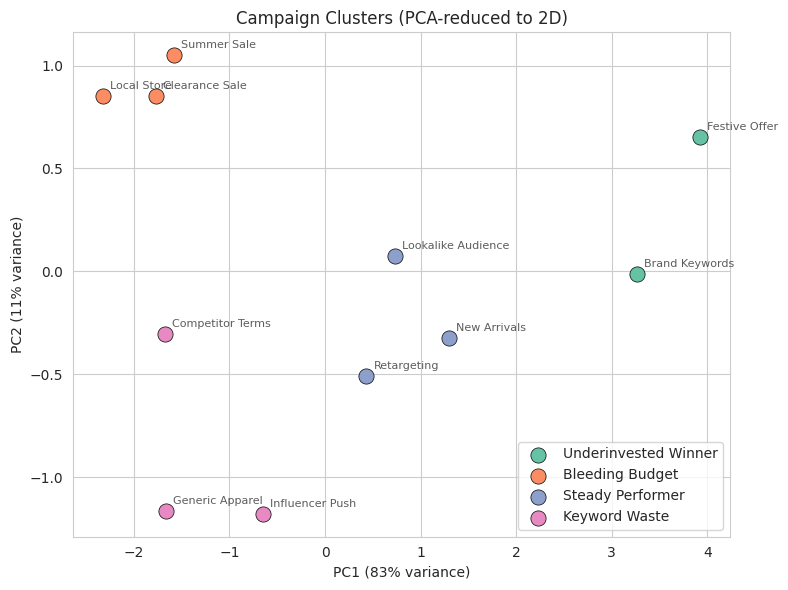

In [9]:
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(scaled_df.values)

plt.figure(figsize=(8, 6))
labels = clustered['cluster_label']
palette = dict(zip(labels.unique(), sns.color_palette('Set2', labels.nunique())))

for label in labels.unique():
    mask = labels == label
    plt.scatter(coords[mask, 0], coords[mask, 1], label=label, s=120,
                color=palette[label], edgecolor='black', linewidth=0.5)

for i, name in enumerate(clustered['campaign_name']):
    plt.annotate(name.split(' - ')[0], (coords[i, 0], coords[i, 1]),
                 fontsize=8, alpha=0.75, xytext=(5, 5), textcoords='offset points')

plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
plt.title('Campaign Clusters (PCA-reduced to 2D)')
plt.legend()
plt.tight_layout()
plt.show()

The four clusters separate cleanly even in this 2D projection (PC1 + PC2 explain most of the variance in the 5-feature space). Underinvested Winners sit clearly apart from the rest — they're both rare and extreme, which becomes important in the next section.

## 5. Isolation Forest — Anomaly Detection

### A real finding worth documenting

The first version of this anomaly detector simply ran Isolation Forest and flagged whatever it called an outlier as `is_anomaly`. That approach **flagged the two best-performing campaigns** (Festive Offer, Brand Keywords) as anomalies, instead of the genuinely wasteful ones.

This isn't a bug — it's a correct description of how Isolation Forest works. It finds statistically *rare* points in feature space with no concept of "good" or "bad." In this account, the high-performing campaigns are the minority, so they're the most isolated points by definition. Meanwhile, the deliberately wasteful campaigns blend in with several other mediocre campaigns and don't look rare at all.

**The fix:** split Isolation Forest's raw output by direction. A campaign is only surfaced as an actionable `is_anomaly` if it is *both* statistically rare *and* underperforming (low ROAS, low conversion rate, meaningful spend). Rare points that are performing *well* are labeled `is_standout` instead — a positive callout rather than an alert.

In [10]:
flagged = detect_anomalies(df)
cols = ['campaign_name', 'cost', 'conversions', 'roas', 'statistical_outlier', 'is_anomaly', 'is_standout', 'anomaly_score']
flagged[cols].sort_values('anomaly_score')

,campaign_name,cost,conversions,roas,statistical_outlier,is_anomaly,is_standout,anomaly_score
5,Festive Offer - Shopping,2169.89,33,0.0152,True,False,True,-0.1133
0,Brand Keywords - Search,1887.03,26,0.0138,True,False,True,-0.0701
10,Influencer Push - Display,3200.00,4,0.0012,True,True,False,-0.0063
1,Summer Sale - Search,8577.65,4,0.0005,True,True,False,-0.0009
3,Generic Apparel - Search,3066.34,0,0.0000,False,False,False,0.0009
9,Local Store - Search,8400.00,0,0.0000,False,False,False,0.0021
4,New Arrivals - Search,2940.88,15,0.0051,False,False,False,0.0118
8,Clearance Sale - Search,7876.80,2,0.0003,False,False,False,0.0168
7,Lookalike Audience - Display,4194.99,14,0.0033,False,False,False,0.0207
6,Competitor Terms - Search,5393.03,0,0.0000,False,False,False,0.0305


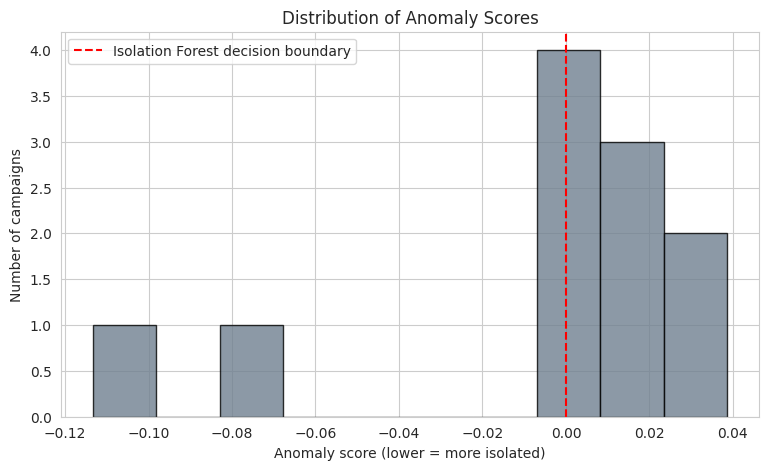

In [11]:
plt.figure(figsize=(9, 5))
plt.hist(flagged['anomaly_score'], bins=10, color='slategray', edgecolor='black', alpha=0.8)
plt.axvline(0, color='red', linestyle='--', label='Isolation Forest decision boundary')
plt.xlabel('Anomaly score (lower = more isolated)')
plt.ylabel('Number of campaigns')
plt.title('Distribution of Anomaly Scores')
plt.legend()
plt.show()

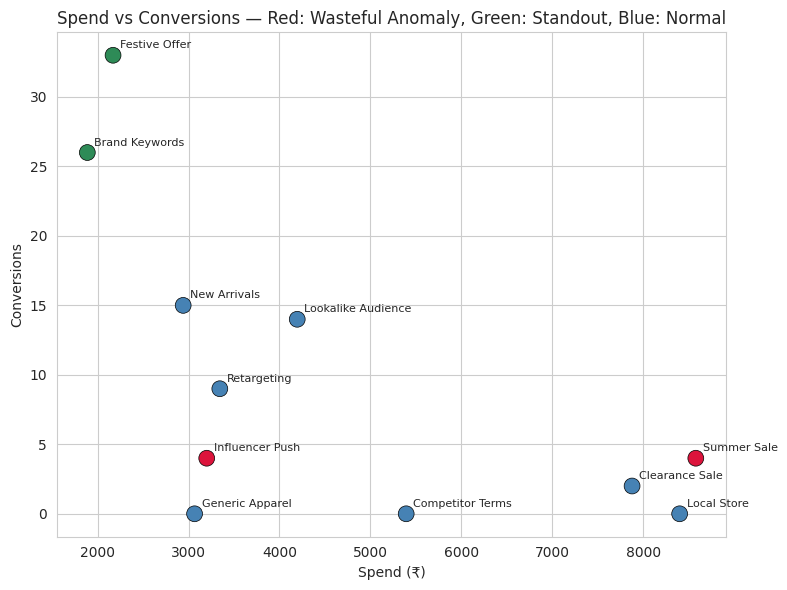

In [12]:
plt.figure(figsize=(8, 6))
colors = flagged.apply(
    lambda r: 'crimson' if r['is_anomaly'] else ('seagreen' if r['is_standout'] else 'steelblue'),
    axis=1
)
plt.scatter(flagged['cost'], flagged['conversions'], c=colors, s=130, edgecolor='black', linewidth=0.5)

for _, row in flagged.iterrows():
    plt.annotate(row['campaign_name'].split(' - ')[0], (row['cost'], row['conversions']),
                 fontsize=8, xytext=(5, 5), textcoords='offset points')

plt.xlabel('Spend (₹)')
plt.ylabel('Conversions')
plt.title('Spend vs Conversions — Red: Wasteful Anomaly, Green: Standout, Blue: Normal')
plt.tight_layout()
plt.show()

**Contamination sensitivity:** the `contamination` parameter controls how wide a net Isolation Forest casts before the directional filter is applied. Too narrow, and the entire budget gets consumed by one direction (we saw this firsthand — at `contamination=0.18`, both flagged outliers were standouts, leaving zero room for wasteful anomalies). The table below shows how the count of flagged anomalies/standouts shifts as contamination increases.

In [13]:
contamination_levels = [0.10, 0.18, 0.25, 0.35, 0.45]
rows = []
for c in contamination_levels:
    result = detect_anomalies(df, contamination=c)
    rows.append({
        'contamination': c,
        'statistical_outliers': result['statistical_outlier'].sum(),
        'wasteful_anomalies': result['is_anomaly'].sum(),
        'standouts': result['is_standout'].sum(),
    })

pd.DataFrame(rows)

,contamination,statistical_outliers,wasteful_anomalies,standouts
0,0.10,1,0,1
1,0.18,2,0,2
2,0.25,3,1,2
3,0.35,4,2,2
4,0.45,5,3,2


At `contamination=0.35` (used in production), both directions get meaningful representation: 2 standouts and 2 wasteful anomalies, out of 11 campaigns. For larger accounts (50+ campaigns), this would need to be tuned down — a fixed proportion doesn't scale linearly with account size, since the *absolute* number of genuinely anomalous campaigns tends to grow much more slowly than the account itself.

## 6. Health Score Derivation

The health score is a deterministic formula, not a model — every step is traceable and explainable to a non-technical stakeholder:

1. **Base score from cluster membership** (Underinvested Winner: 75, Steady Performer: 60, Keyword Waste: 35, Bleeding Budget: 25)
2. **Metric adjustment** (±4 to ±10) based on how the campaign's CTR, conversion rate, and CPC compare to the account average — so two campaigns in the same cluster aren't scored identically
3. **Anomaly penalty** (−15) if flagged as a wasteful anomaly
4. **Standout bonus** (+10) if flagged as a positive standout
5. Clipped to 0–100, then bucketed into Excellent / Good / Average / Poor

The Claude API (next stage of the pipeline, not covered in this notebook) explains this score in natural language — it never recalculates or overrides it.

In [14]:
merged = clustered.merge(
    flagged[['campaign_name', 'statistical_outlier', 'is_anomaly', 'is_standout', 'anomaly_score']],
    on='campaign_name'
)
scored = compute_health_scores(merged)

cols = ['campaign_name', 'cluster_label', 'is_anomaly', 'is_standout', 'health_score', 'health_category']
scored[cols].sort_values('health_score', ascending=False)

,campaign_name,cluster_label,is_anomaly,is_standout,health_score,health_category
0,Brand Keywords - Search,Underinvested Winner,False,True,95,Excellent
5,Festive Offer - Shopping,Underinvested Winner,False,True,95,Excellent
4,New Arrivals - Search,Steady Performer,False,False,70,Good
7,Lookalike Audience - Display,Steady Performer,False,False,68,Good
2,Retargeting - Display,Steady Performer,False,False,62,Good
6,Competitor Terms - Search,Keyword Waste,False,False,27,Poor
3,Generic Apparel - Search,Keyword Waste,False,False,25,Poor
8,Clearance Sale - Search,Bleeding Budget,False,False,21,Poor
9,Local Store - Search,Bleeding Budget,False,False,15,Poor
10,Influencer Push - Display,Keyword Waste,True,False,12,Poor


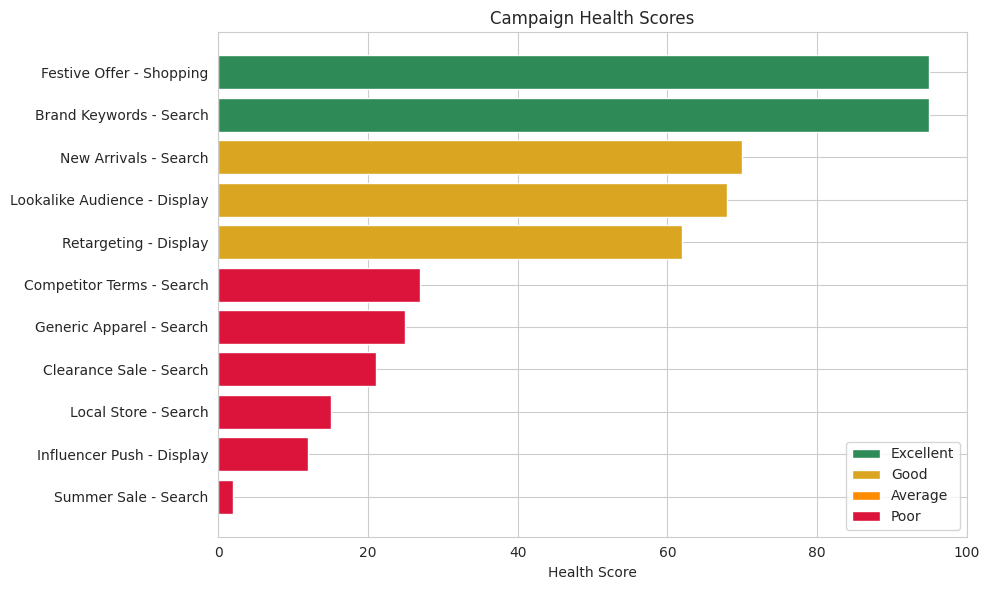

In [15]:
plt.figure(figsize=(10, 6))
category_colors = {'Excellent': 'seagreen', 'Good': 'goldenrod', 'Average': 'darkorange', 'Poor': 'crimson'}
colors = scored['health_category'].map(category_colors)

order = scored.sort_values('health_score', ascending=True)
plt.barh(order['campaign_name'], order['health_score'], color=order['health_category'].map(category_colors))
plt.xlabel('Health Score')
plt.title('Campaign Health Scores')
plt.xlim(0, 100)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=l) for l, c in category_colors.items()]
plt.legend(handles=legend_elements, loc='lower right')
plt.tight_layout()
plt.show()

The score distribution tells a coherent story: the two Underinvested Winners sit at the top (95), Steady Performers cluster comfortably in the Good range, and Keyword Waste / Bleeding Budget campaigns sit at the bottom — with the two campaigns *also* flagged as wasteful anomalies (Summer Sale, Influencer Push) scoring lowest of all, since they stack the anomaly penalty on top of an already-poor cluster base.

## 7. Summary

**What this notebook demonstrates:**

- A CSV parsing layer that survives real-world messiness (tested separately, validated here against clean input)
- Feature engineering that deliberately excludes scale-dependent raw counts in favor of normalized performance ratios
- K-Means clustering with an elbow-method justification for k, and a labeling scheme that reads cluster centroids rather than hardcoding cluster indices
- Isolation Forest anomaly detection — including a genuine model limitation discovered during development (direction-agnostic outlier detection flagging top performers as anomalies) and the directional business-rule fix applied on top of it
- A fully deterministic, explainable health score that combines both models with raw metric comparisons

**Not yet covered here (built separately):**

- The SQL analytics layer (aggregations, window functions, CTEs) that will sit between raw upload and this pipeline in production
- The Claude API integration that turns this structured output into natural-language, cluster-aware recommendations
- The FastAPI backend and React dashboard that serve this pipeline as a product